In [9]:
import pandas as pd
import os
import random

print("Initiated: Fusing Images and Text Data...")

# 1. SEARCH FOR THE PSORIASIS IMAGES FOLDER
image_dir = None
for root, dirs, files in os.walk('/kaggle/input'):
    if 'Psoriasis' in root and 'train' in root:
        image_dir = root
        break

# If found, collect paths for all images (.jpg, .jpeg, .png)
if image_dir:
    image_paths = [os.path.join(image_dir, img) for img in os.listdir(image_dir) if img.endswith(('.jpg', '.jpeg', '.png'))]
    print(f" Found {len(image_paths)} Psoriasis images.")
else:
    print("Error: Could not find Psoriasis image folder.")

# 2. SEARCH FOR THE PATIENT TEXT REVIEW FILE
text_file = None
print("Searching everywhere for the text dataset...")

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        # Look for any file with 'train' in its name ending with .tsv or .csv
        if 'train' in file.lower() and (file.endswith('.tsv') or file.endswith('.csv')):
            text_file = os.path.join(root, file)
            break
    if text_file:
        break

# 3. LOAD AND FILTER TEXT REVIEWS
if text_file:
    print(f" SUCCESS! Found text dataset at: {text_file}")
    
    # Automatically handle formatting separator (Tab for .tsv, Comma for .csv)
    if text_file.endswith('.tsv'):
        df_text = pd.read_csv(text_file, sep='\t')
    else:
        df_text = pd.read_csv(text_file)

    # Keep only Psoriasis rows and drop any empty patient reviews
    psoriasis_text = df_text[df_text['condition'] == 'Psoriasis'].dropna(subset=['review'])
    print(f"Found {len(psoriasis_text)} Psoriasis patient reviews.")

    # 4. MAP NUMERICAL RATINGS TO MEDICAL SEVERITY CATEGORIES
    def get_severity(rating):
        if rating <= 4: return "Severe"      # Low satisfaction rating = high discomfort
        elif rating <= 7: return "Moderate"  # Mid rating = moderate condition
        else: return "Mild"                  # High satisfaction rating = symptoms well-managed

    psoriasis_text['Severity_Label'] = psoriasis_text['rating'].apply(get_severity)

    # 5. RANDOMIZED MULTIMODAL PAIRING
    # Pair items based on the smaller group count to ensure matching sizes
    total_pairs = min(len(image_paths), len(psoriasis_text))
    random.shuffle(image_paths) # Shuffle images to mix up combinations

    # Merge rows pairing 1 image path with 1 patient text entry
    master_data = []
    for i in range(total_pairs):
        row = {
            'Image_Path': image_paths[i],
            'Patient_Text': psoriasis_text.iloc[i]['review'],
            'Severity_Label': psoriasis_text.iloc[i]['Severity_Label']
        }
        master_data.append(row)

    # 6. EXPORT FINAL MASTER DATASET
    master_df = pd.DataFrame(master_data)
    output_filename = "dermo_social_master.csv"
    master_df.to_csv(output_filename, index=False)

    print(f"Saved {total_pairs} Multimodal Pairs to '{output_filename}'.")
    display(master_df.head(3))
else:
    # Error logging fallback to output visible files if text folder path fails
    print(" Error: Still couldn't find the text file. Here are the files Kaggle can see:")
    for root, dirs, files in os.walk('/kaggle/input'):
        for file in files:
            print(f" - {os.path.join(root, file)}")

Initiated: Fusing Images and Text Data...
 Found 1405 Psoriasis images.
Searching everywhere for the text dataset...
 SUCCESS! Found text dataset at: /kaggle/input/datasets/jessicali9530/kuc-hackathon-winter-2018/drugsComTrain_raw.csv
Found 598 Psoriasis patient reviews.
Saved 598 Multimodal Pairs to 'dermo_social_master.csv'.


,Image_Path,Patient_Text,Severity_Label
0,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I have used Halobetasol Propionate 0.05% for ...",Mild
1,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I just started Humira the beginning of this m...",Mild
2,/kaggle/input/datasets/shubhamgoel27/dermnet/t...,"""I developed a severe case of psoriasis soon a...",Mild


In [10]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.preprocessing import image
import os

print("Initiated: Waking up DenseNet121...")

# 1. LOAD THE MASTER DATASET FROM PHASE 1
df = pd.read_csv("dermo_social_master.csv")
print(f"Loaded {len(df)} image paths from Phase 1.")

# 2. LOAD PRE-TRAINED DENSENET121 MODEL
# include_top=False removes the generic classification layer so we grab raw features instead of final guesses.
# pooling='avg' flattens the deep visual patterns into a clean 1,024-dimensional numerical vector.
print("Downloading/Loading DenseNet121 weights...")
base_model = DenseNet121(weights='imagenet', include_top=False, pooling='avg')

# 3. FUNCTION TO PROCESS AND EXTRACT VISUAL SIGNALS FROM A SINGLE IMAGE
def extract_image_features(img_path):
    try:
        # Load the image and resize it to the standard 224x224 pixels required by DenseNet
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0) # Add batch dimension required by TensorFlow
        
        # Preprocess pixel intensities to match ImageNet training data standard
        img_array = preprocess_input(img_array)
        
        # Forward pass through network to convert image into high-level geometric descriptors
        features = base_model.predict(img_array, verbose=0)
        return features[0]
    except Exception as e:
        # If an image file is corrupted or missing, return a vector of zeros as a safe fallback
        print(f" Error reading {img_path}")
        return np.zeros(1024)

# 4. BATCH ITERATION PROCESSOR FOR ALL IMAGE PATHS
print("🔍 Scanning all 598 images. This might take 1-2 minutes...")
vision_features = []

for i, path in enumerate(df['Image_Path']):
    # Log tracking statements every 100 iterations to watch progress
    if i > 0 and i % 100 == 0:
        print(f"   ... Processed {i} images so far")
    
    vec = extract_image_features(path)
    vision_features.append(vec)

# Package all image arrays into a single fast-access matrix
vision_features = np.array(vision_features)

# 5. SERIALIZE MATRIX TO DISK FOR REUSE IN DOWNSTREAM ALGORITHMS
np.save("vision_features.npy", vision_features)

print(f" Extracted a matrix of shape {vision_features.shape} and saved to 'vision_features.npy'")

Initiated: Waking up DenseNet121...
Loaded 598 image paths from Phase 1.
Downloading/Loading DenseNet121 weights...
🔍 Scanning all 598 images. This might take 1-2 minutes...
   ... Processed 100 images so far
   ... Processed 200 images so far
   ... Processed 300 images so far
   ... Processed 400 images so far
   ... Processed 500 images so far
 Extracted a matrix of shape (598, 1024) and saved to 'vision_features.npy'


In [12]:
import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertModel
import warnings
warnings.filterwarnings('ignore') 

print("Initiated: Waking up DistilBERT (The Semantic Stream)...")

# 1. LOAD THE MASTER DATASET AND EXTRACT PATIENT REVIEWS
df = pd.read_csv("dermo_social_master.csv")
texts = df['Patient_Text'].tolist()
print(f" Loaded {len(texts)} patient reviews.")

# 2. LOAD PRE-TRAINED DISTILBERT MODEL AND TOKENIZER
print(" Downloading/Loading DistilBERT weights & tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
model = DistilBertModel.from_pretrained('distilbert-base-uncased')

# 3. CONFIGURE HARDWARE ACCELERATION (GPU fallback to CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Running on device: {device}")

# 4. BATCH PROCESSOR FUNCTION FOR TEXT EXTRACTION
def extract_text_features(text_list, batch_size=16):
    all_features = []
    model.eval() # Freeze model layers (deactivates training-only behaviors like dropout)
    
    with torch.no_grad(): # Disable gradient calculations to maximize execution speed and save memory
        for i in range(0, len(text_list), batch_size):
            batch_texts = text_list[i:i+batch_size]
            
            if i > 0 and i % 100 < batch_size:
                print(f"   ... Processed {i} text reviews so far")
            
            # Tokenize: Convert text strings into uniform, model-readable numerical tensors
            inputs = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt").to(device)
            
            # Forward Pass: Extract deep linguistic representation vectors
            outputs = model(**inputs)
            
            # Grab the [CLS] token embedding, which acts as a dense summary vector of the entire text sentence
            cls_embeddings = outputs.last_hidden_state[:, 0, :]
            all_features.append(cls_embeddings.cpu().numpy())
            
    return np.vstack(all_features)

# 5. EXECUTE PIPELINE OVER NARRATIVES
print("Reading patient minds... Extracting features. This is usually very fast!")
semantic_features = extract_text_features(texts)

# 6. SAVE COMPACT SEMANTIC MATRIX TO DISK
np.save("semantic_features.npy", semantic_features)

print(f" Extracted a matrix of shape {semantic_features.shape} and saved to 'semantic_features.npy'")

Initiated: Waking up DistilBERT (The Semantic Stream)...
 Loaded 598 patient reviews.
 Downloading/Loading DistilBERT weights & tokenizer...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Running on device: cpu
Reading patient minds... Extracting features. This is usually very fast!
   ... Processed 112 text reviews so far
   ... Processed 208 text reviews so far
   ... Processed 304 text reviews so far
   ... Processed 400 text reviews so far
   ... Processed 512 text reviews so far
 Extracted a matrix of shape (598, 768) and saved to 'semantic_features.npy'


In [13]:
import pandas as pd
import numpy as np
import random
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("Initiated: Commencing Feature Fusion & Evolution...")

# 1. LOAD EXTRACTED DATA STREAMS
df = pd.read_csv("dermo_social_master.csv")
vision_features = np.load("vision_features.npy")
semantic_features = np.load("semantic_features.npy")

# 2. MULTIMODAL FEATURE FUSION
# Horizontally stack the 1024 DenseNet features and 768 DistilBERT features together
X_fused = np.hstack((vision_features, semantic_features))
print(f"Fused Feature Matrix Shape: {X_fused.shape}")

# 3. ENCODE HEALTH TARGETS AND SPLIT DATA
le = LabelEncoder()
y = le.fit_transform(df['Severity_Label']) # Convert text labels to integers (0, 1, 2)
classes = le.classes_
print(f"Target Classes: {classes}")

# Segment the unified multi-stream data into an 80-20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.2, random_state=42)

# 4. GENETIC ALGORITHM PARAMETERS & FITNESS FUNCTION
POPULATION_SIZE = 10  
GENERATIONS = 5       
MUTATION_RATE = 0.1   
TOTAL_FEATURES = X_fused.shape[1]

def calculate_fitness(chromosome):
    # Extract indices where the binary switch is active (value == 1)
    selected_indices = np.where(chromosome == 1)[0]
    
    # Penalize chromosomes that accidentally deactivate all feature switches
    if len(selected_indices) == 0:
        return 0.0 
    
    # Slice matrices to isolate only the selected subset of genes/features
    X_train_subset = X_train[:, selected_indices]
    X_test_subset = X_test[:, selected_indices]
    
    # Train a baseline model to measure the predictive power of this feature subset
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
    rf.fit(X_train_subset, y_train)
    preds = rf.predict(X_test_subset)
    return accuracy_score(y_test, preds)

# 5. EVOLUTIONARY OPTIMIZATION ENGINE
print(f"\n🔬 Starting Genetic Evolution for {GENERATIONS} Generations...")

# Initialize a random starting population of binary chromosomes
population = [np.random.randint(2, size=TOTAL_FEATURES) for _ in range(POPULATION_SIZE)]

best_chromosome_ever = None
best_fitness_ever = 0.0

for gen in range(GENERATIONS):
    # Run fitness scoring for every candidate solution in the current generation
    fitness_scores = [calculate_fitness(chrom) for chrom in population]
    
    # Track global elite solution across all generations
    best_gen_fitness = max(fitness_scores)
    if best_gen_fitness > best_fitness_ever:
        best_fitness_ever = best_gen_fitness
        best_chromosome_ever = population[np.argmax(fitness_scores)]
        
    print(f"   Generation {gen+1} | Best Accuracy: {best_gen_fitness * 100:.2f}%")
    
    # Selection: Sort the population and preserve the top 50% highest-scoring parents
    sorted_population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda pair: pair[0], reverse=True)]
    parents = sorted_population[:POPULATION_SIZE // 2]
    
    # Crossover & Mutation: Repopulate the generation pool
    next_generation = []
    while len(next_generation) < POPULATION_SIZE:
        p1, p2 = random.sample(parents, 2)
        crossover_point = random.randint(1, TOTAL_FEATURES - 1)
        child = np.concatenate((p1[:crossover_point], p2[crossover_point:]))
        
        # Randomly flip bits based on mutation probability to maintain genetic diversity
        if random.random() < MUTATION_RATE:
            mutation_point = random.randint(0, TOTAL_FEATURES - 1)
            child[mutation_point] = 1 - child[mutation_point]
            
        next_generation.append(child)
        
    population = next_generation

# 6. EXPORT THE OPTIMAL FEATURE MASK
optimal_feature_indices = np.where(best_chromosome_ever == 1)[0]
np.save("optimal_features_indices.npy", optimal_feature_indices)

print(f"Evolution finished! The GA reduced {TOTAL_FEATURES} features down to {len(optimal_feature_indices)} optimal features.")
print(f"Highest Accuracy Achieved: {best_fitness_ever * 100:.2f}%")

Initiated: Commencing Feature Fusion & Evolution...
Fused Feature Matrix Shape: (598, 1792)
Target Classes: ['Mild' 'Moderate' 'Severe']

🔬 Starting Genetic Evolution for 5 Generations...
   Generation 1 | Best Accuracy: 84.17%
   Generation 2 | Best Accuracy: 84.17%
   Generation 3 | Best Accuracy: 85.00%
   Generation 4 | Best Accuracy: 85.00%
   Generation 5 | Best Accuracy: 85.00%
Evolution finished! The GA reduced 1792 features down to 925 optimal features.
Highest Accuracy Achieved: 85.00%


Initiating Final Binary Multimodal Pipeline...
 Synthesizing minority cases using SMOTE...

Starting Genetic Evolution for 5 Generations...
    Generation 1 | Best Balanced Score: 66.67%
    Generation 2 | Best Balanced Score: 69.05%
    Generation 3 | Best Balanced Score: 69.05%
    Generation 4 | Best Balanced Score: 68.04%
    Generation 5 | Best Balanced Score: 68.04%

 Training Final Classifier on Optimal Features...

 FINAL BINARY ACCURACY: 87.50%

CLASSIFICATION REPORT (Watch the Severe Recall increase!):
              precision    recall  f1-score   support

  Non-Severe       0.88      0.99      0.93        99
      Severe       0.88      0.33      0.48        21

    accuracy                           0.88       120
   macro avg       0.88      0.66      0.71       120
weighted avg       0.88      0.88      0.85       120



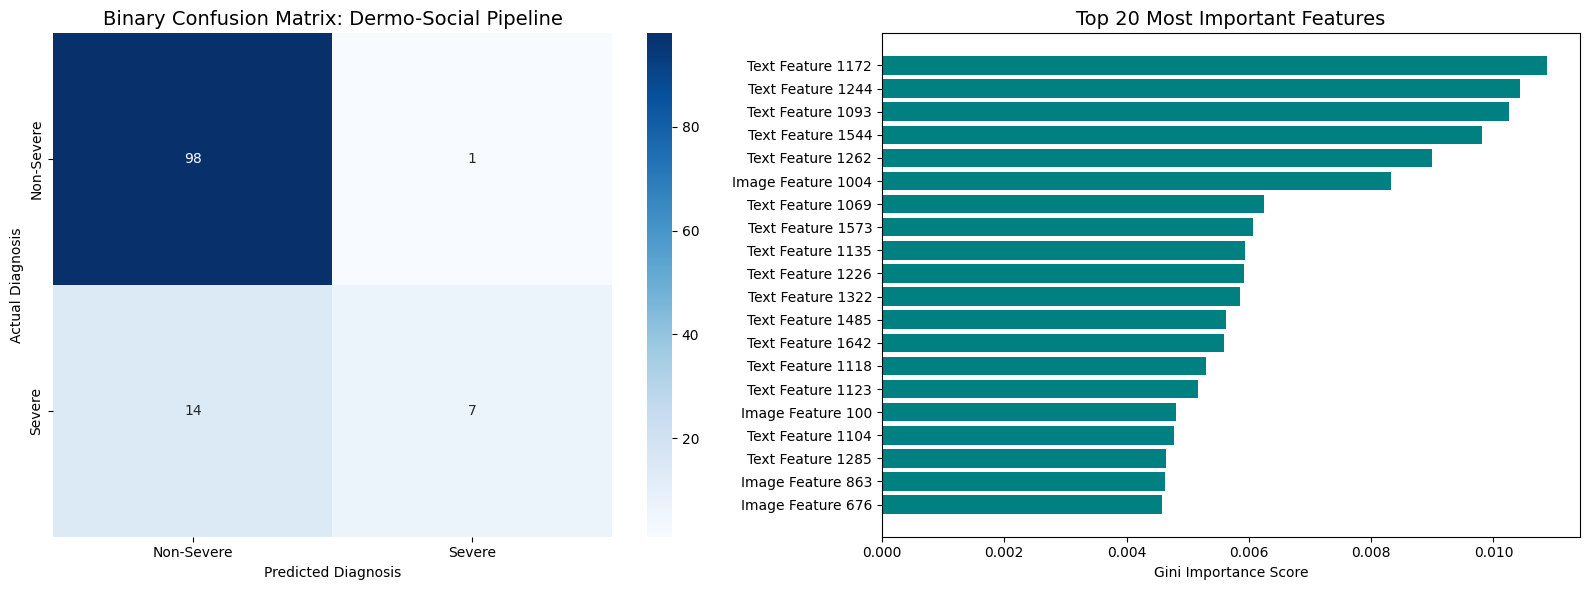

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, balanced_accuracy_score
from imblearn.over_sampling import SMOTE
import random
import warnings
warnings.filterwarnings('ignore')

print("Initiating Final Binary Multimodal Pipeline...")

# 1. CONVERT MULTI-CLASS TARGETS TO BINARY LABELS
df = pd.read_csv("dermo_social_master.csv")
# Group Mild into 'Non-Severe' and group Moderate/Severe together into 'Severe'
df['Severity_Label'] = df['Severity_Label'].replace({'Mild': 'Non-Severe', 'Moderate': 'Severe', 'Severe': 'Severe'})

# 2. LOAD AND FUSE MULTI-STREAM ARRAYS
vision_features = np.load("vision_features.npy")
semantic_features = np.load("semantic_features.npy")
X_fused = np.hstack((vision_features, semantic_features)) # Combine spatial and text embeddings
TOTAL_FEATURES = X_fused.shape[1]

# 3. LABEL ENCODING AND SEPARATION
le = LabelEncoder()
y = le.fit_transform(df['Severity_Label']) # Convert binary text strings to 0 and 1
classes = le.classes_

# Create train/test splits (80% training, 20% validation)
X_train, X_test, y_train, y_test = train_test_split(X_fused, y, test_size=0.2, random_state=42)

# 4. DATA AUGMENTATION VIA SMOTE
print(" Synthesizing minority cases using SMOTE...")
# Over-sample the training partition to create a 50/50 balanced training split
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 5. GENETIC ALGORITHM FOR DISCRIMINATIVE FEATURE SELECTION
POPULATION_SIZE = 10  
GENERATIONS = 5       
MUTATION_RATE = 0.1   

def calculate_fitness(chromosome):
    # Locate active feature indices where bit value equals 1
    selected_indices = np.where(chromosome == 1)[0]
    if len(selected_indices) == 0: return 0.0 
    
    X_train_subset = X_train_smote[:, selected_indices]
    X_test_subset = X_test[:, selected_indices]
    
    # Evaluate feature subsets using cost-sensitive learning (class_weight='balanced')
    rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, class_weight='balanced')
    rf.fit(X_train_subset, y_train_smote)
    
    # Calculate fitness score using balanced accuracy to protect minority class recall
    return balanced_accuracy_score(y_test, rf.predict(X_test_subset))

print(f"\nStarting Genetic Evolution for {GENERATIONS} Generations...")
population = [np.random.randint(2, size=TOTAL_FEATURES) for _ in range(POPULATION_SIZE)]
best_chromosome_ever = None
best_fitness_ever = 0.0

for gen in range(GENERATIONS):
    fitness_scores = [calculate_fitness(chrom) for chrom in population]
    best_gen_fitness = max(fitness_scores)
    
    # Maintain elite history tracking
    if best_gen_fitness > best_fitness_ever:
        best_fitness_ever = best_gen_fitness
        best_chromosome_ever = population[np.argmax(fitness_scores)]
        
    print(f"    Generation {gen+1} | Best Balanced Score: {best_gen_fitness * 100:.2f}%")
    
    # Selection: Retain top performing candidate solutions
    sorted_population = [x for _, x in sorted(zip(fitness_scores, population), key=lambda pair: pair[0], reverse=True)]
    parents = sorted_population[:POPULATION_SIZE // 2]
    
    # Crossover and Mutation processing loop
    next_generation = []
    while len(next_generation) < POPULATION_SIZE:
        p1, p2 = random.sample(parents, 2)
        crossover_point = random.randint(1, TOTAL_FEATURES - 1)
        child = np.concatenate((p1[:crossover_point], p2[crossover_point:]))
        
        if random.random() < MUTATION_RATE:
            mutation_point = random.randint(0, TOTAL_FEATURES - 1)
            child[mutation_point] = 1 - child[mutation_point] 
        next_generation.append(child)
    population = next_generation

# 6. FINAL PIPELINE PERFORMANCE EVALUATION
optimal_indices = np.where(best_chromosome_ever == 1)[0]
X_train_final = X_train_smote[:, optimal_indices]
X_test_final = X_test[:, optimal_indices]

print("\n Training Final Classifier on Optimal Features...")
rf_final = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced')
rf_final.fit(X_train_final, y_train_smote)

y_pred = rf_final.predict(X_test_final)
final_accuracy = accuracy_score(y_test, y_pred)

print(f"\n FINAL BINARY ACCURACY: {final_accuracy * 100:.2f}%\n")
print("CLASSIFICATION REPORT (Watch the Severe Recall increase!):")
print(classification_report(y_test, y_pred, target_names=classes))

# 7. GENERATE DUAL-PANEL GRAPHICAL METRICS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Binary Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Binary Confusion Matrix: Dermo-Social Pipeline', fontsize=14)
axes[0].set_xlabel('Predicted Diagnosis')
axes[0].set_ylabel('Actual Diagnosis')

# Panel 2: Mapped Feature Importance scores (Top 20)
importances = rf_final.feature_importances_
top_indices_local = np.argsort(importances)[-20:] 
top_importances = importances[top_indices_local]

feature_origins = []
for idx in top_indices_local:
    original_feature_index = optimal_indices[idx]
    # Check boundaries to trace feature back to DenseNet (0-1023) or DistilBERT (1024+)
    if original_feature_index < 1024:
        feature_origins.append(f"Image Feature {original_feature_index}")
    else:
        feature_origins.append(f"Text Feature {original_feature_index}")

axes[1].barh(range(20), top_importances, color='teal')
axes[1].set_yticks(range(20))
axes[1].set_yticklabels(feature_origins)
axes[1].set_title('Top 20 Most Important Features', fontsize=14)
axes[1].set_xlabel('Gini Importance Score')

plt.tight_layout()
plt.show()